 
#  Baseline Modeling for Ames Housing
 
### This notebook builds a baseline model using LightGBM and a simple Ridge blend.


# 1. Imports and configuration


In [1]:
import sys
from pathlib import Path
# Add src to path (if not installed as package)
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import logging
logging.basicConfig(level=logging.INFO)

from src import config
from src.data import load_train, load_test
from src.features import FeatureTransformer, log_transform_target, inverse_log_transform
from src.cv import get_folds
from src.models import get_lgb, get_ridge
from src.train import train_model_oof
from src.ensemble import oof_blend
from src.inference import predict_test
from src.utils import rmse

# 2. Load and clean data

In [2]:
df = load_train()
print(f"Train shape: {df.shape}")

# Remove known extreme outliers (as per Kaggle discussions)
df = df.drop(df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)].index)
print(f"After outlier removal: {df.shape}")

Train shape: (1460, 81)
After outlier removal: (1458, 81)


# 3. Feature transformation

In [3]:
# Separate target
y_raw = df[config.TARGET]
X_raw = df.drop([config.TARGET, "Id"], axis=1)

# Fit transformer on full training data (for OOF we need to do it inside CV, but here we just want to see transformation)
transformer = FeatureTransformer()
transformer.fit(X_raw)
X_processed = transformer.transform(X_raw)

# Log transform target
if config.LOG_TARGET:
    y = log_transform_target(y_raw)
else:
    y = y_raw

print(f"Processed features shape: {X_processed.shape}")

INFO:src.features:Skewed features to transform: ['MSSubClass', 'LotArea', '1stFlrSF', 'GrLivArea']


Processed features shape: (1458, 84)


# 4. Simple LightGBM with OOF

In [4]:
# 4. Proper LightGBM OOF (no leakage, correct target handling)
from src.ensemble import oof_lgb

# Use raw target (original SalePrice)
oof_preds_lgb_raw, models_lgb = oof_lgb(X_raw, y_raw, n_splits=config.N_SPLITS)

# Compute RMSE on original scale
rmse_orig_lgb = rmse(y_raw, oof_preds_lgb_raw)
print(f"LightGBM OOF RMSE (original scale): {rmse_orig_lgb:.2f}")

INFO:src.features:Skewed features to transform: ['MSSubClass', 'LotArea', '1stFlrSF', 'GrLivArea']
/home/madzimest/anaconda3/lib/python3.10/site-packages/lightgbm/basic.py:1780: UserWarning: Overriding the parameters from Reference Dataset.
  _log_warning('Overriding the parameters from Reference Dataset.')
/home/madzimest/anaconda3/lib/python3.10/site-packages/lightgbm/basic.py:1513: UserWarning: categorical_column in param dict is overridden.
  _log_warning(f'{cat_alias} in param dict is overridden.')
INFO:src.ensemble:Fold 1 RMSE: 28501.66109
INFO:src.features:Skewed features to transform: ['MSSubClass', 'LotArea', '1stFlrSF', 'GrLivArea', 'KitchenAbvGr']
/home/madzimest/anaconda3/lib/python3.10/site-packages/lightgbm/basic.py:1780: UserWarning: Overriding the parameters from Reference Dataset.
  _log_warning('Overriding the parameters from Reference Dataset.')
/home/madzimest/anaconda3/lib/python3.10/site-packages/lightgbm/basic.py:1513: UserWarning: categorical_column in param dic

LightGBM OOF RMSE (original scale): 24581.04


# 5. Blending LightGBM + Ridge

In [5]:
# Reset X and y to raw (the blending function does its own transformation per fold)
# We pass the raw X (without preprocessing) and raw y (log-transformed)
oof_preds_blend, models_blend = oof_blend(X_raw, y, n_splits=config.N_SPLITS)

rmse_blend_orig = rmse(inverse_log_transform(y), inverse_log_transform(oof_preds_blend))
print(f"Blend OOF RMSE (original scale): {rmse_blend_orig:.2f}")

INFO:src.ensemble:Fold 1/10
INFO:src.features:Skewed features to transform: ['MSSubClass', 'LotArea', '1stFlrSF', 'GrLivArea']
/home/madzimest/anaconda3/lib/python3.10/site-packages/lightgbm/basic.py:1780: UserWarning: Overriding the parameters from Reference Dataset.
  _log_warning('Overriding the parameters from Reference Dataset.')
/home/madzimest/anaconda3/lib/python3.10/site-packages/lightgbm/basic.py:1513: UserWarning: categorical_column in param dict is overridden.
  _log_warning(f'{cat_alias} in param dict is overridden.')
INFO:src.ensemble:Fold RMSE: 0.10987
INFO:src.ensemble:Fold 2/10
INFO:src.features:Skewed features to transform: ['MSSubClass', 'LotArea', '1stFlrSF', 'GrLivArea', 'KitchenAbvGr']
/home/madzimest/anaconda3/lib/python3.10/site-packages/lightgbm/basic.py:1780: UserWarning: Overriding the parameters from Reference Dataset.
  _log_warning('Overriding the parameters from Reference Dataset.')
/home/madzimest/anaconda3/lib/python3.10/site-packages/lightgbm/basic.py:

Blend OOF RMSE (original scale): 21180.09


## Save the blend models for later use

In [7]:
from src.utils import save_models
save_models(models_blend, config.MODEL_DIR / "blend_run1")


#from src.utils import load_models
#loaded_models = load_models(config.MODEL_DIR / "blend_run1")
#test_preds_loaded = predict_test(loaded_models, test_raw)


#rmse_blend_log = np.sqrt(mean_squared_error(y, oof_preds_blend))
#print(f"Blend OOF RMSE (log scale): {rmse_blend_log:.5f}")

# 6. Feature importance (from the first fold LGB)

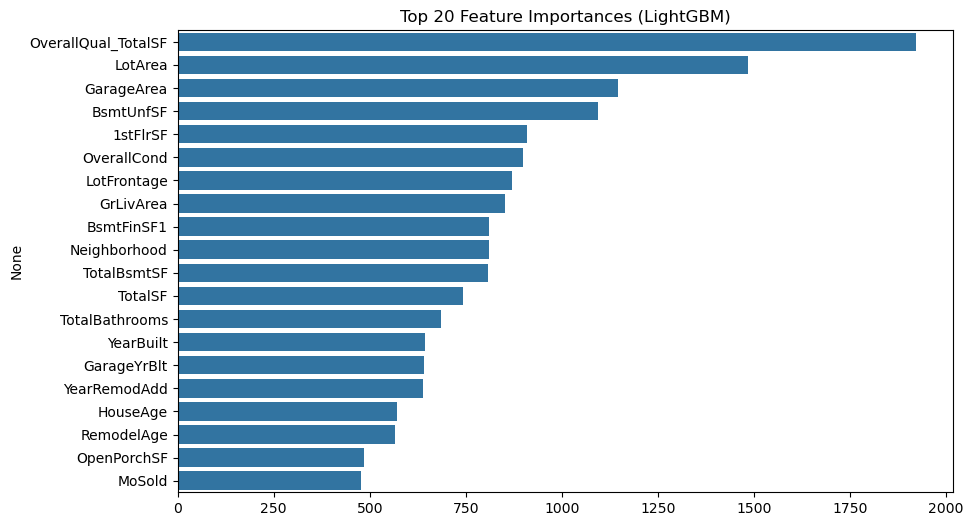

In [8]:
# Take the first fold's LGB model
lgb_fold0 = models_blend[0]["lgb"]
importance = lgb_fold0.feature_importances_
feat_names = models_blend[0]["ft"].transform(X_raw).columns   # after transformation
# Plot top 20
import matplotlib.pyplot as plt
import seaborn as sns
feat_imp = pd.Series(importance, index=feat_names).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top 20 Feature Importances (LightGBM)")
plt.show()

# 7. Predict on test set

In [9]:
test_df = load_test()
test_ids = test_df["Id"]
test_raw = test_df.drop("Id", axis=1)

test_preds = predict_test(models_blend, test_raw)

# Create submission
submission = pd.DataFrame({"Id": test_ids, "SalePrice": test_preds})
submission.to_csv(config.SUBMISSION_FILE, index=False)
print(f"Submission saved to {config.SUBMISSION_FILE}")

Submission saved to /home/madzimest/Documents/ReactJS/MyPortifolio/DataScience/DS/notebooks/submission.csv
